# 📊 Exploratory Data Analysis (EDA)
**Project:** Credit Risk Engine
* **Dataset:** Taiwan Credit Default Risk (30,000 clientes)
* **Objetive:** Predecir `default payment_next_month`
* **Values:** (0 = default no , 1 = default)

In [103]:
# SECTION 1: IMPORT LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [104]:
# SECTION 2: LOAD DATASET
df = pd.read_csv("../data/raw/credit_card_default.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [105]:
# SECTION 3: DATA QUALITY CHECK
df.info()
print("Missing values:\n", df.isnull().sum()) 
print("Duplicated rows:", df.duplicated().sum()) 
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


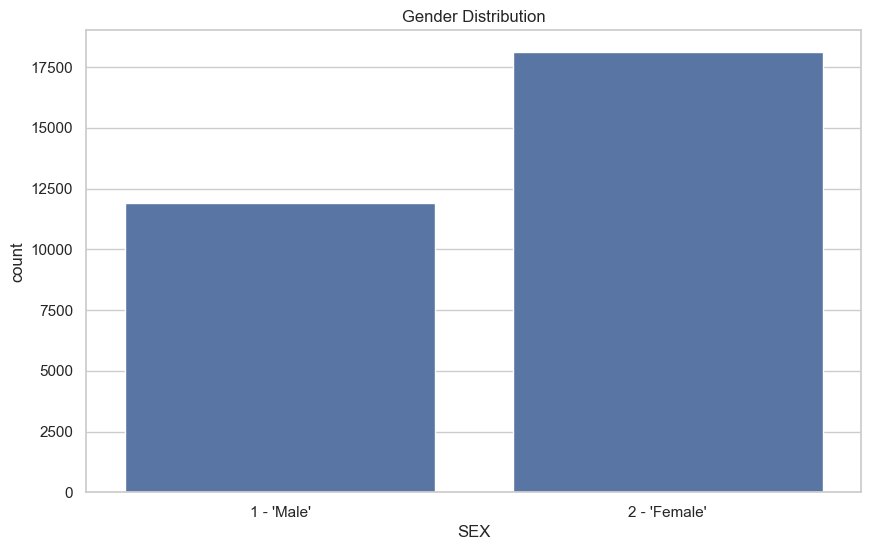

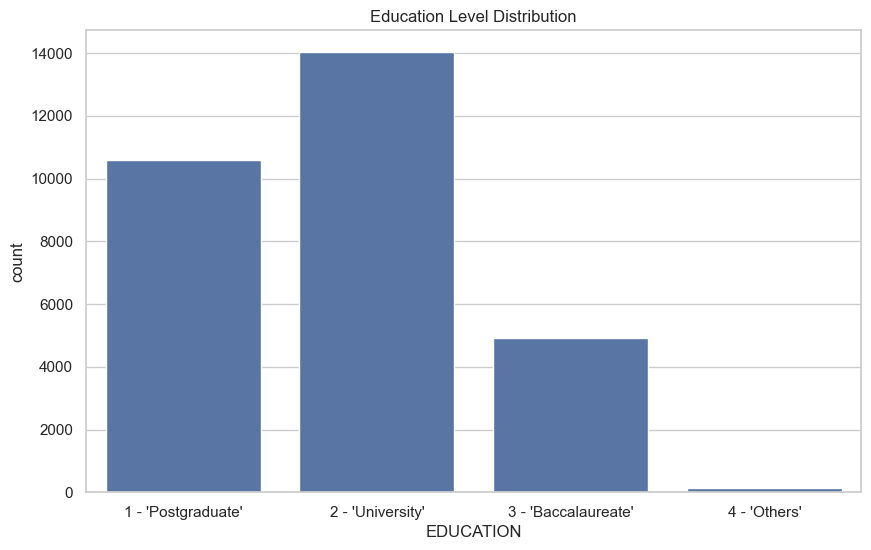

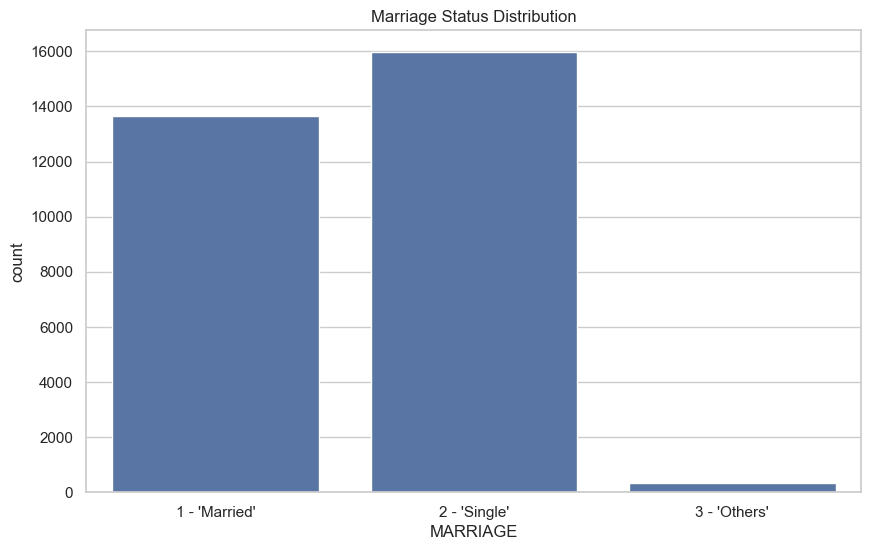

In [106]:
# SECTION 4: UNIVARIABLE ANALYSIS - CATEGORIAL VARIABLES


# --- Graph 1: SEX --- 
sns.countplot(x="SEX", data=df) 
plt.title("Gender Distribution") 
plt.xticks([0, 1], ["1 - 'Male'", "2 - 'Female'"])
plt.show()

 
# --- Graph 2: EDUCATION --- 
df_edu = df[df["EDUCATION"].isin([1, 2, 3, 4])]
sns.countplot(x="EDUCATION", data=df_edu, order=[1, 2, 3, 4])
plt.title("Education Level Distribution")
plt.xticks([0, 1, 2, 3], ["1 - 'Postgraduate'", "2 - 'University'", "3 - 'Baccalaureate'", "4 - 'Others'"])
plt.show()


# --- Graph 2: MARRIAGE --- 
df_mar = df[df["MARRIAGE"].isin([1, 2, 3])]
sns.countplot(x="MARRIAGE", data=df_mar, order=[1, 2, 3])
plt.title("Marriage Status Distribution")
plt.xticks([0, 1, 2], ["1 - 'Married'", "2 - 'Single'", "3 - 'Others'"])
plt.show()






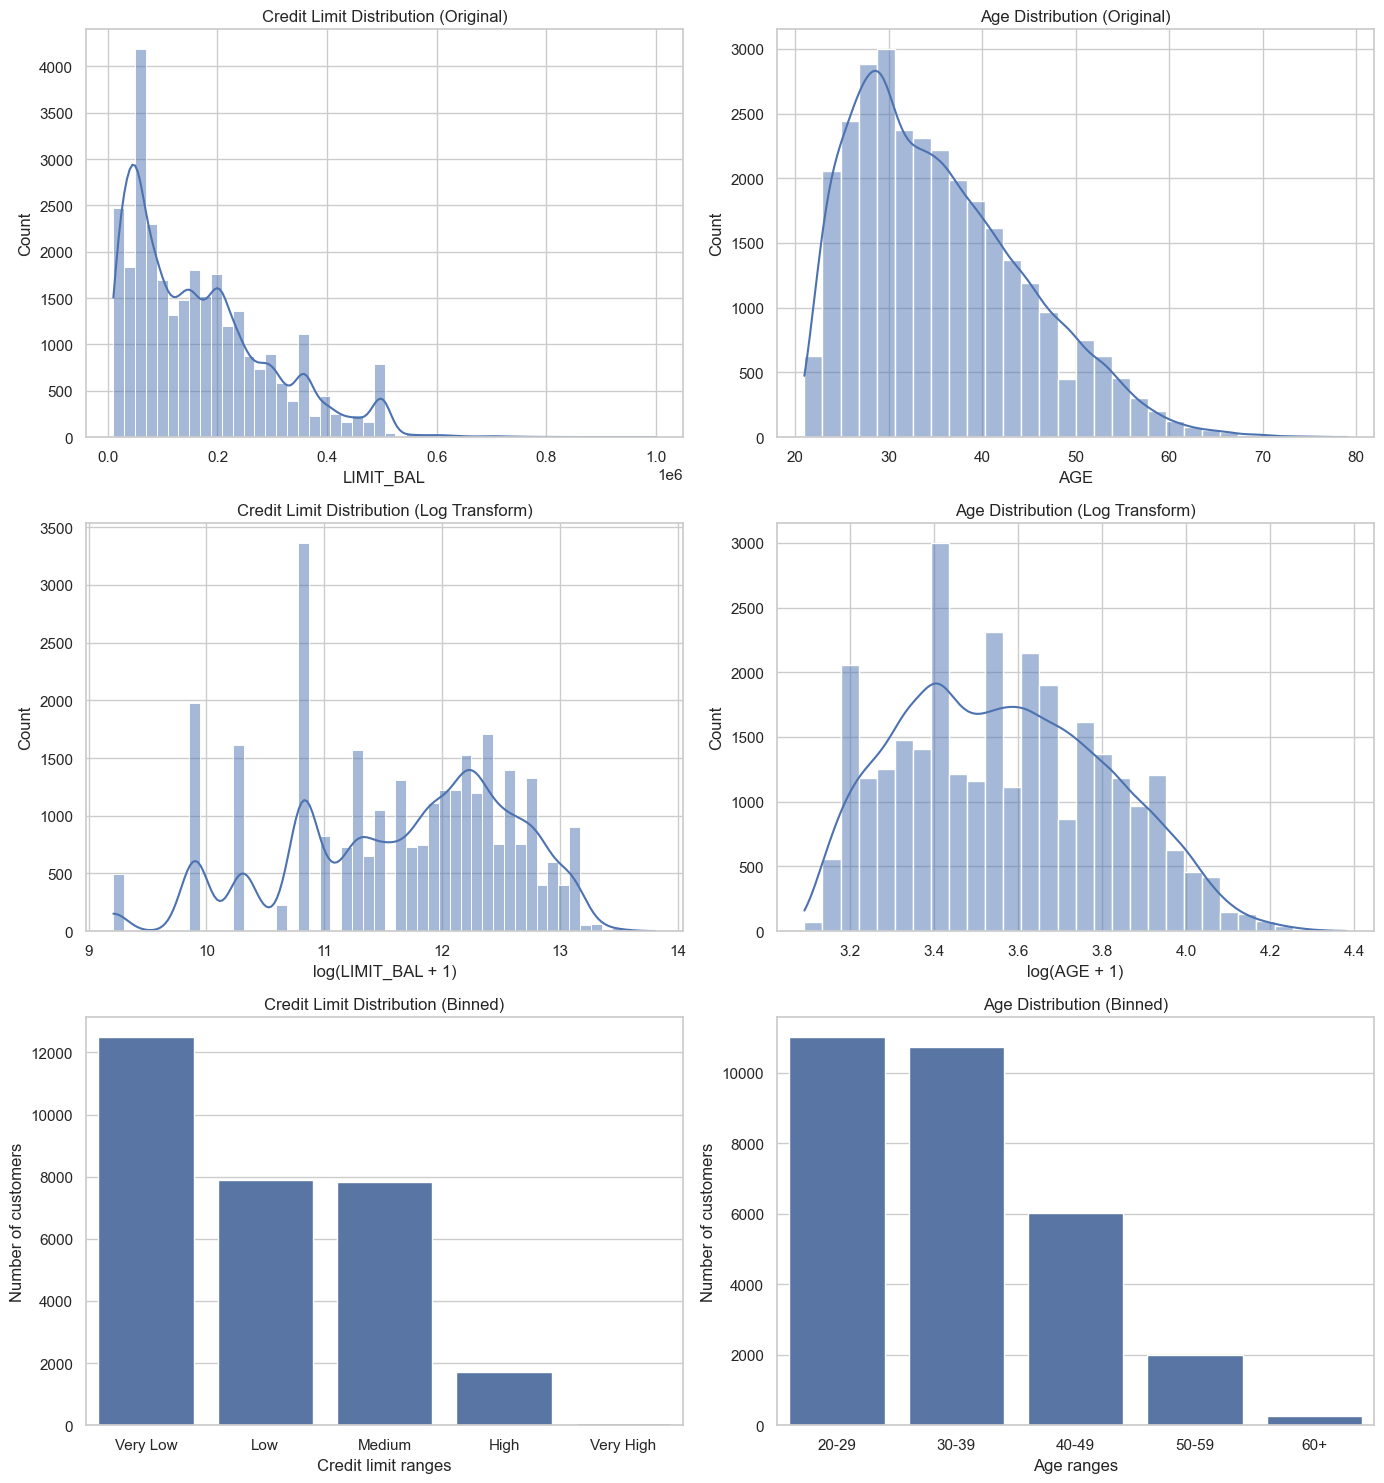

In [107]:
# SECTION 5: UNIVARIABLE ANALYSIS - NUMERAL  VARIABLES

# Define bins para LIMIT_BAL y AGE 
bins_credit = [0, 100000, 200000, 400000, 600000, 1000000] 
# labels_credit = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"] 
labels_credit = ["Very Low", "Low", "Medium", "High", "Very High"]
df["LIMIT_BAL_BIN"] = pd.cut(df["LIMIT_BAL"], bins=bins_credit, labels=labels_credit)

bins_age = [20, 30, 40, 50, 60, 80] 
labels_age = ["20-29", "30-39", "40-49", "50-59", "60+"] 
df["AGE_BIN"] = pd.cut(df["AGE"], bins=bins_age, labels=labels_age)

# Create a shape with 2 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# --- Graphic 1: Original Credit Limit ---
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True, ax=axes[0,0]) 
axes[0,0].set_title("Credit Limit Distribution (Original)") 
axes[0,0].set_xlabel("LIMIT_BAL")


# --- Graphic 2: Original Age ---
sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[0,1]) 
axes[0,1].set_title("Age Distribution (Original)") 
axes[0,1].set_xlabel("AGE")

# --- Graphic 3: Log Transform Credit Limit --- 
sns.histplot(np.log1p(df["LIMIT_BAL"]), bins=50, kde=True, ax=axes[1,0]) 
axes[1,0].set_title("Credit Limit Distribution (Log Transform)") 
axes[1,0].set_xlabel("log(LIMIT_BAL + 1)") 

# --- Graphic 4: Log Transform Age --- 
sns.histplot(np.log1p(df["AGE"]), bins=30, kde=True, ax=axes[1,1]) 
axes[1,1].set_title("Age Distribution (Log Transform)") 
axes[1,1].set_xlabel("log(AGE + 1)") 

# --- Graphic 5: Binning --- 
sns.countplot(x="LIMIT_BAL_BIN", data=df, ax=axes[2,0]) 
axes[2,0].set_title("Credit Limit Distribution (Binned)") 
axes[2,0].set_xlabel("Credit limit ranges") 
axes[2,0].set_ylabel("Number of customers") 

sns.countplot(x="AGE_BIN", data=df, ax=axes[2,1]) 
axes[2,1].set_title("Age Distribution (Binned)") 
axes[2,1].set_xlabel("Age ranges") 
axes[2,1].set_ylabel("Number of customers")

plt.tight_layout() 
plt.show()

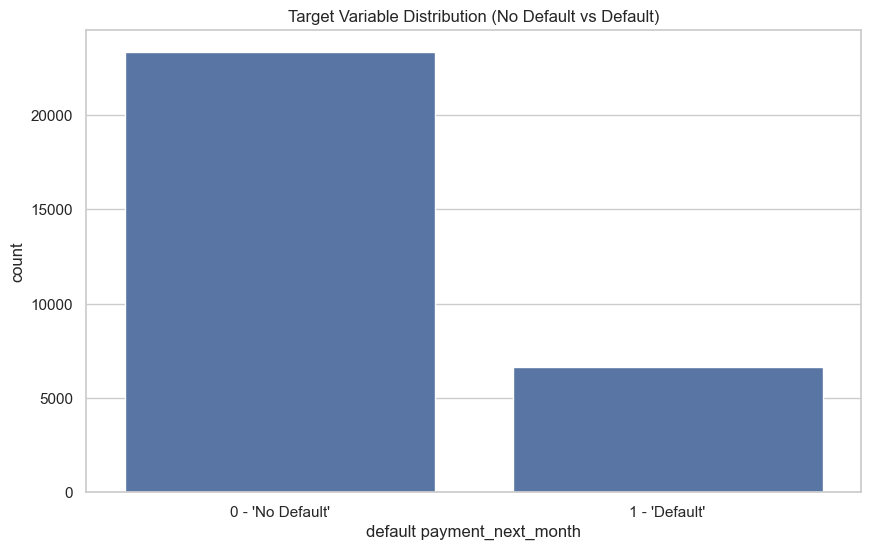

default payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [108]:
# SECTION 6: TARGET VARIABLE
sns.countplot(x="default payment_next_month", data=df)
plt.title("Target Variable Distribution (No Default vs Default)")
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show()

df["default payment_next_month"].value_counts(normalize=True)

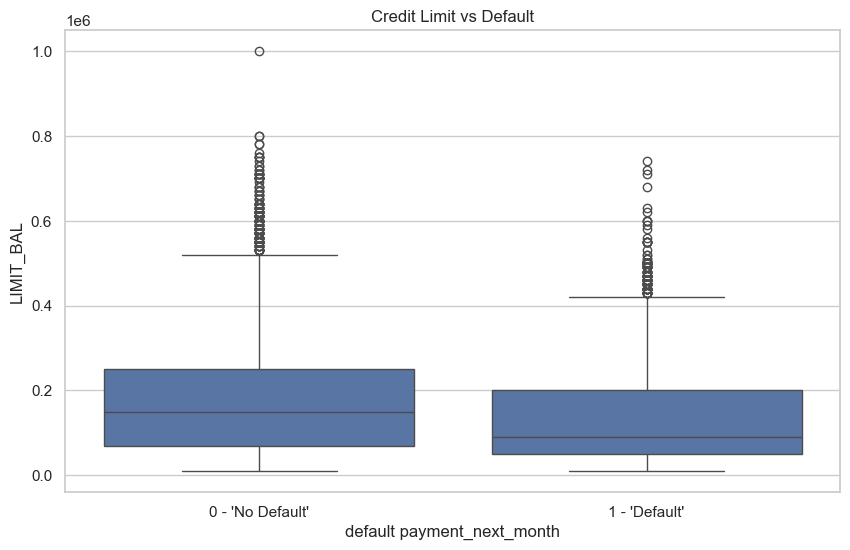

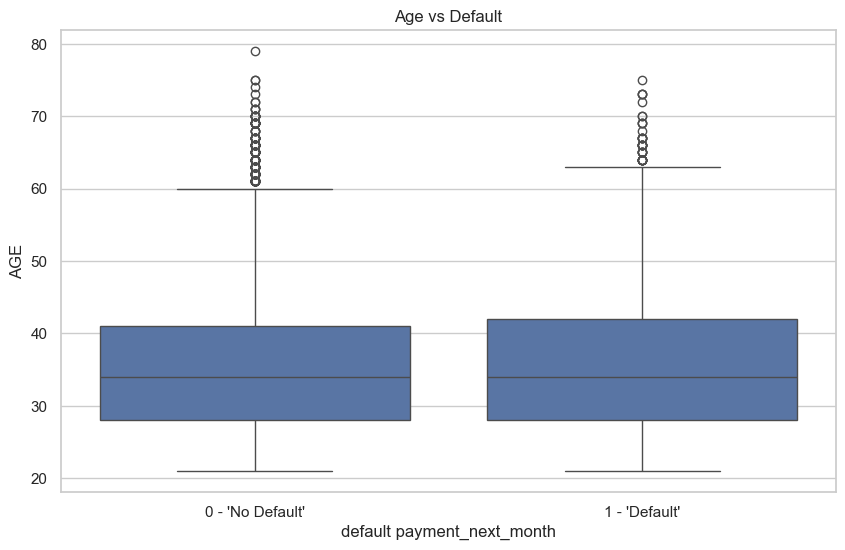

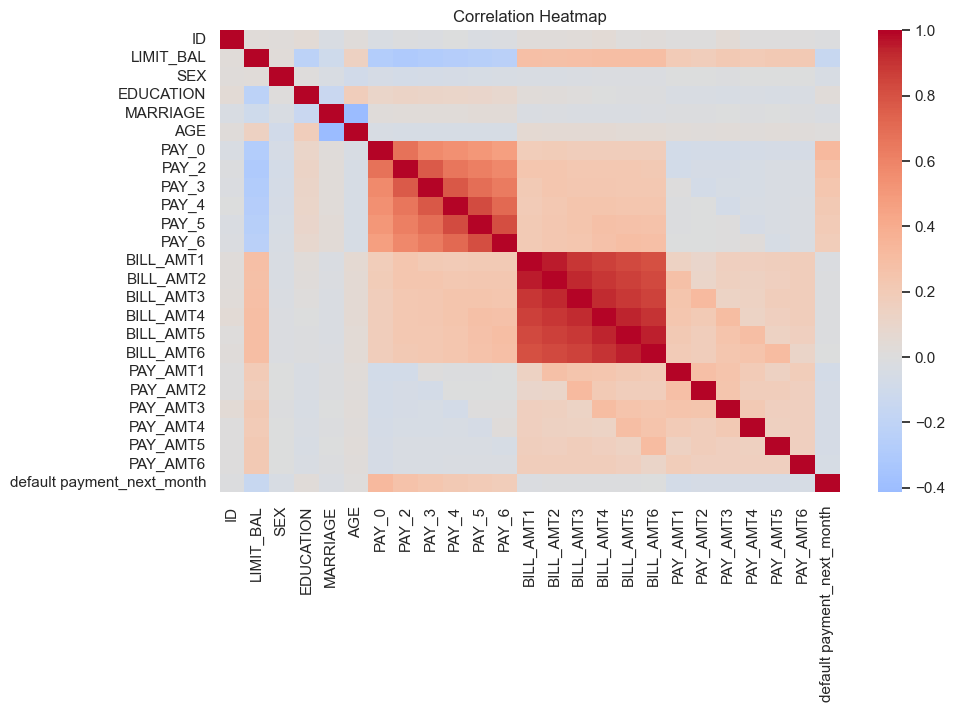

In [109]:
# SECTION 7: BIVARIATE ANALYSIS
sns.boxplot(x="default payment_next_month", y="LIMIT_BAL", data=df) 
plt.title("Credit Limit vs Default") 
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show()
 
sns.boxplot(x="default payment_next_month", y="AGE", data=df) 
plt.title("Age vs Default") 
plt.xticks([0, 1], ["0 - 'No Default'", "1 - 'Default'"])
plt.show() 

corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [110]:
# SECTION 8: PATTERS AND HYPOTHESES
mar_default = pd.crosstab(df["MARRIAGE"], df["default payment_next_month"], normalize="index") 
print("Default rate by Marriage:\n", mar_default)

edu_default = pd.crosstab(df["EDUCATION"], df["default payment_next_month"], normalize="index") 
print("Default rate by Education:\n", edu_default) 

sex_default = pd.crosstab(df["SEX"], df["default payment_next_month"], normalize="index")
print("Default rate by Sex:\n", sex_default)

Default rate by Marriage:
 default payment_next_month         0         1
MARRIAGE                                      
0                           0.907407  0.092593
1                           0.765283  0.234717
2                           0.790717  0.209283
3                           0.739938  0.260062
Default rate by Education:
 default payment_next_month         0         1
EDUCATION                                     
0                           1.000000  0.000000
1                           0.807652  0.192348
2                           0.762651  0.237349
3                           0.748424  0.251576
4                           0.943089  0.056911
5                           0.935714  0.064286
6                           0.843137  0.156863
Default rate by Sex:
 default payment_next_month         0         1
SEX                                           
1                           0.758328  0.241672
2                           0.792237  0.207763


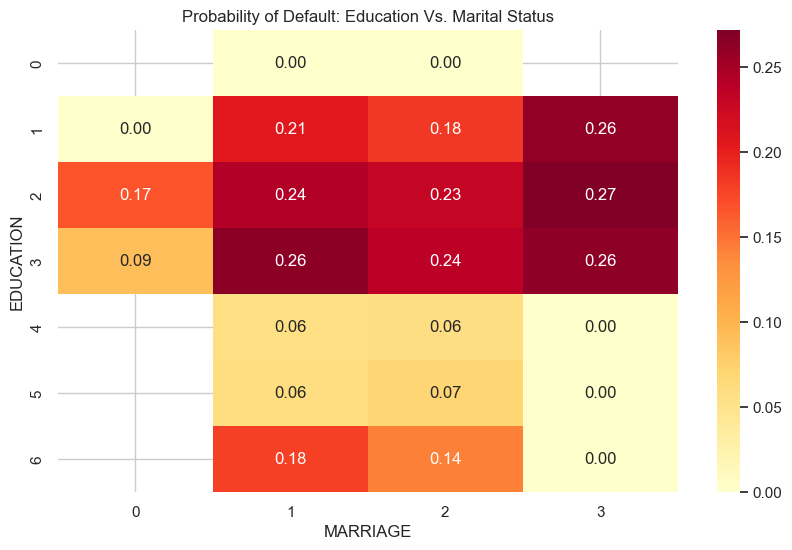

In [111]:
# SECTION 9: RISK INTERSECTION ANALYSIS
# We created a pivot table to see the cross-default rate
pivot_risk = df.pivot_table(index='EDUCATION', columns='MARRIAGE', 
                            values='default payment_next_month', aggfunc='mean')


plt.figure(figsize=(10, 6))
sns.heatmap(pivot_risk, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Probability of Default: Education Vs. Marital Status')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7032\298001276.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pay_0_risk.index, y=pay_0_risk.values, palette="magma")


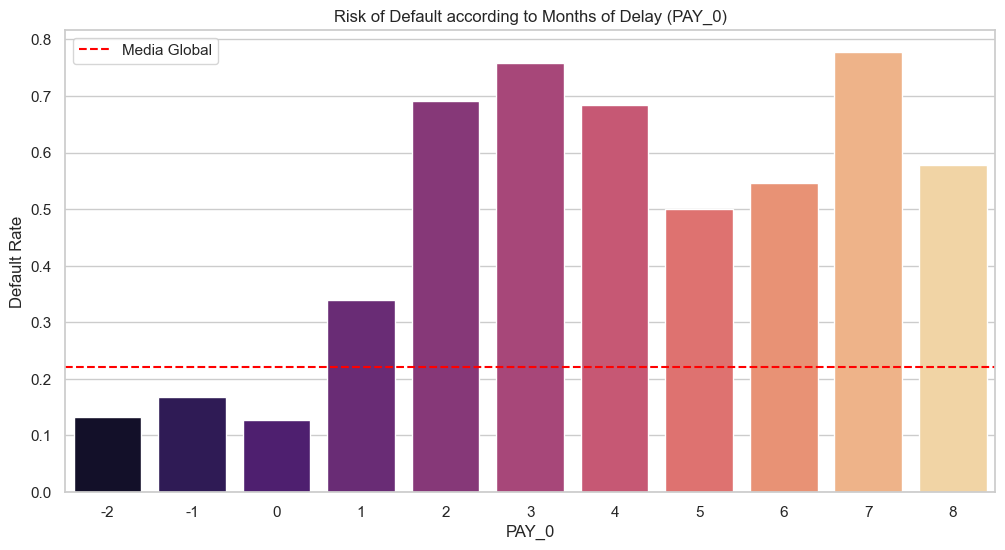

In [112]:
# SECTION 10: FINANCIAL BEHAVIOR ANALYSIS
# 9.1. Impact of payment delay (PAY_0)
plt.figure(figsize=(12, 6))
# We calculate the default rate by PAY_0 category
pay_0_risk = df.groupby('PAY_0')['default payment_next_month'].mean()

sns.barplot(x=pay_0_risk.index, y=pay_0_risk.values, palette="magma")
plt.axhline(y=df['default payment_next_month'].mean(), color='red', linestyle='--', label='Media Global')
plt.title('Risk of Default according to Months of Delay (PAY_0)')
plt.ylabel('Default Rate')
plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7032\2411861875.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='default payment_next_month', y='UTILIZATION_1',


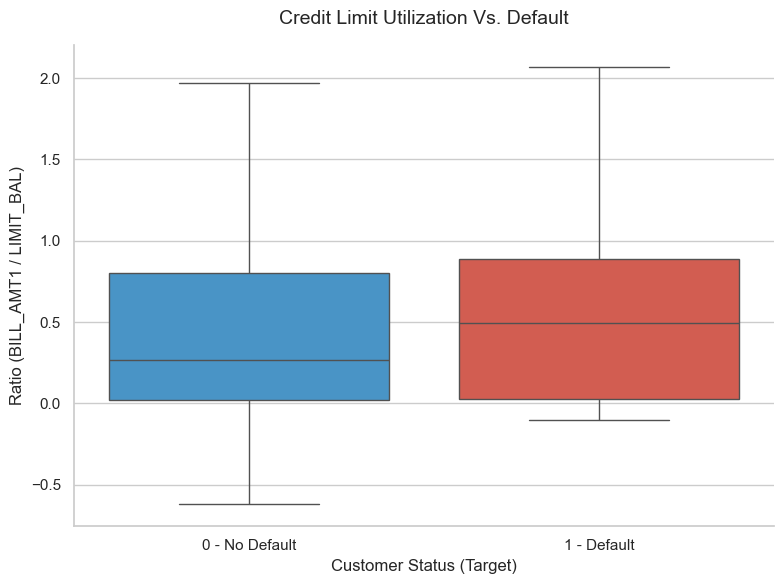

In [113]:
# SECTION 10: FINANCIAL BEHAVIOR ANALYSIS
#9.2. Utilization Ratio (Debt / Limit)
# We created the variable (Feature Engineering for the EDA)
df['UTILIZATION_1'] = df['BILL_AMT1'] / df['LIMIT_BAL']

plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df, x='default payment_next_month', y='UTILIZATION_1', 
                 showfliers=False, palette=['#3498db', '#e74c3c'])

plt.xticks(ticks=[0, 1], labels=['0 - No Default', '1 - Default'], fontsize=11)

plt.title('Credit Limit Utilization Vs. Default', fontsize=14, pad=15)
plt.xlabel('Customer Status (Target)', fontsize=12)
plt.ylabel('Ratio (BILL_AMT1 / LIMIT_BAL)', fontsize=12)

sns.despine() 
plt.tight_layout()
plt.show()



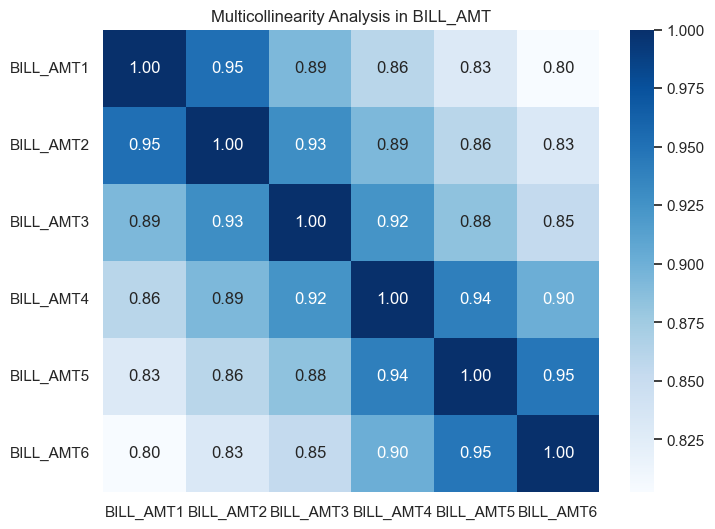

In [114]:
# SECTION 10: FINANCIAL BEHAVIOR ANALYSIS
# 9.3. Correlation in Billing Amounts
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
plt.figure(figsize=(8, 6))
sns.heatmap(df[bill_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Multicollinearity Analysis in BILL_AMT')
plt.show()

# SECTION 11: EXPLORATORY ANALYSIS AND KEY FINDINGS


## 1. Class Imbalance & Data Quality

- **Default rate:** 22.1% → strong class imbalance.
- Accuracy is not sufficient → use **F1-Score, Precision-Recall, AUC-ROC**.
- **30,000 records** with no missing or duplicate values.

---

## 2. Sociodemographic Factors

- **Postgraduate:** 19% default (lower risk).
- **University/High School:** ~24–25% (higher risk).
- **Men:** 24.1% vs **Women:** 20.7%.
- **Married clients** show slightly higher risk than **single clients**.

---

## 3. Financial Predictors

- `PAY_0` → strongest predictor.
  - More months of delay ⇒ higher default probability.
- Lower `LIMIT_BAL` → higher default frequency.

---

## 4. Preprocessing Insights

- High multicollinearity in `BILL_AMT1–6` ($r > 0.90$).
  - Apply **PCA** or create an **Average Debt** feature.
- Scale variables (`AGE`, `BILL_AMT`) before training.